In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import bot
import constants
import curling_nn
import data_generation
import scratch.value_network_data
import dataset
import nn
import stats

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)

%load_ext autoreload
%autoreload 2


## value network (second-to-last throw)


In [2]:
value_network = curling_nn.ValueNetwork(
    seed=0, num_stones=9, hidden_layer_size=20
)
value_loss_function = nn.SoftmaxCrossEntropyLoss()


In [3]:
generate_new_value_data = False
value_shard_names = None # default to loading all saved data

if generate_new_value_data:
    value_shard_paths = scratch.value_network_data.write_value_network_training_data_shards(
        output_dir=constants.value_network_datasets_dir,
        team1=5,
        team2=4,
        team=1,
        num_sims=1000000,
        seed=6823,
        sheet_batch_size=32,
    )
    value_shard_names = [path.rsplit('/', 1)[-1] for path in value_shard_paths]
    print(f"value shards available: {len(value_shard_names)}")

value_data = dataset.load_training_data_dir(
    constants.value_network_datasets_dir, names=value_shard_names
)
print(f"value dataset size: {value_data.size()}")


value dataset size: 374704


In [4]:
value_data, value_validation_data = value_data.partition(0.2, seed=0)


In [85]:
value_losses = []
value_val_losses = []
num_points_per_batch = 100
num_iters = 30

for i in range(num_iters):
    lr = 0.01 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in value_data.shuffle_batches(num_points_per_batch, seed=None):
        value_network.train_batched(
            batch,
            value_loss_function,
            lr,
            0,
        )

    value_losses.append(
        value_network.get_average_loss_batched(
            value_data.input_features, value_data.answers, value_loss_function
        )
    )
    value_val_losses.append(
        value_network.get_average_loss_batched(
            value_validation_data.input_features,
            value_validation_data.answers,
            value_loss_function,
        )
    )


In [6]:
constants.value_network_weights_path

'/home/vietafan/curling/weights/value_network_weights.npz'

In [23]:
num_parameters = curling_nn.print_trainable_parameter_info(value_network)

ValueNetwork: 9 input stones, hidden layer size 20
  linear layer 0: weights (20, 46), bias (20, 1), parameters 940
  linear layer 1: weights (20, 20), bias (20, 1), parameters 420
  linear layer 2: weights (20, 20), bias (20, 1), parameters 420
  linear layer 3: weights (11, 20), bias (11, 1), parameters 231
total trainable parameters: 2011


In [29]:
curling_nn.write_v_weights(
    '/home/vietafan/curling/weights/value_network_weights_train_320k_v2.npz',
    value_network,
    value_data.normalizer,
)
print(f"wrote weights to {constants.value_network_weights_path}")


wrote weights to /home/vietafan/curling/weights/value_network_weights.npz


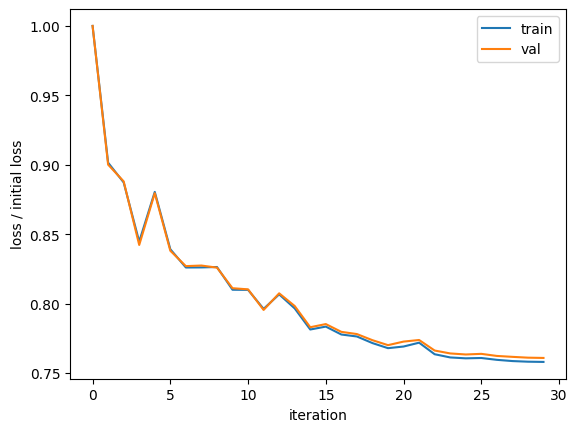

<Axes: xlabel='iteration', ylabel='loss / initial loss'>

In [28]:
stats.plot_training_losses(value_losses, value_val_losses)


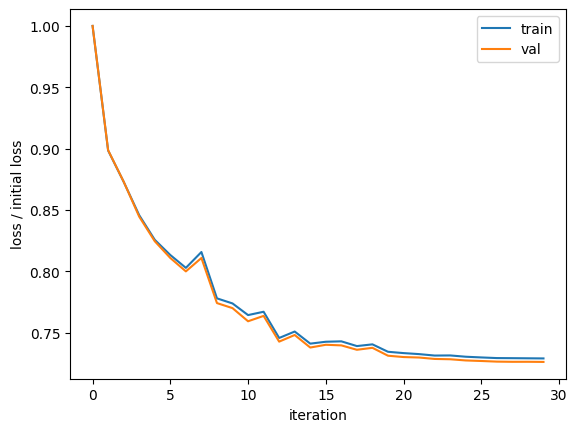

<Axes: xlabel='iteration', ylabel='loss / initial loss'>

In [83]:
stats.plot_training_losses(value_losses, value_val_losses)

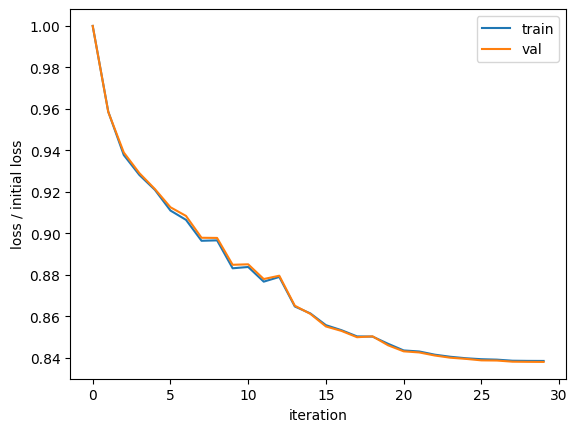

<Axes: xlabel='iteration', ylabel='loss / initial loss'>

In [86]:
stats.plot_training_losses(value_losses, value_val_losses)

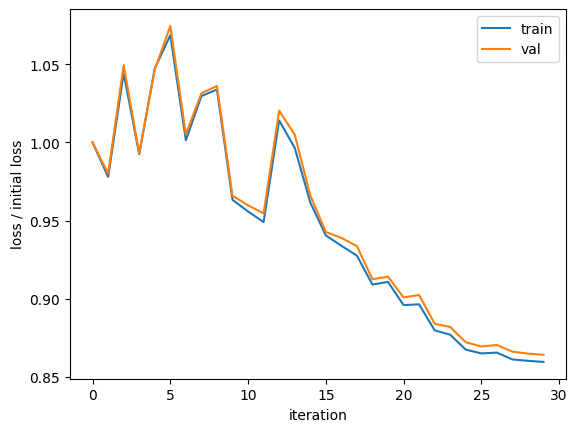

<Axes: xlabel='iteration', ylabel='loss / initial loss'>

In [9]:
stats.plot_training_losses(value_losses, value_val_losses)


In [11]:
value_network, normalizer = curling_nn.load_v_weights(
   #   constants.value_network_weights_path
  #   '/home/vietafan/curling/weights/value_network_weights_train_320k_v2.npz'
    "/home/vietafan/curling/weights/scaling_laws_old/value_n300000_h30.npz"
  )


expected-score R²: 0.638 ± 0.000
P(actual score): 0.523 ± 0.001
negative log P(actual): 0.867 ± 0.003


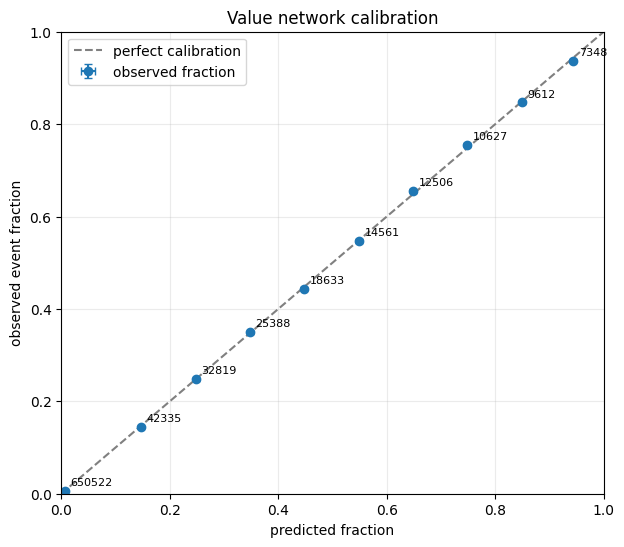

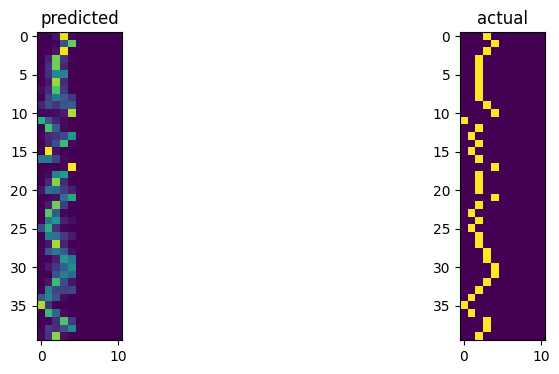

array([<Axes: title={'center': 'predicted'}>,
       <Axes: title={'center': 'actual'}>], dtype=object)

In [9]:
value_predictions = stats.create_prediction_dataframe(
    value_network,
    value_validation_data,
    score_values=np.arange(-5, 6),
)
value_stats = stats.compute_stats(value_predictions, seed=0)
stats.print_stats(value_stats)
stats.plot_calibration(value_stats, title="Value network calibration")
stats.plot_score_heatmaps(
    nn.softmax(value_network.run(value_validation_data.input_features[:, :, None])),
    value_validation_data.answers,
)


expected-score R²: 0.624 ± 0.000
P(actual score): 0.516 ± 0.001
negative log P(actual): 0.877 ± 0.003


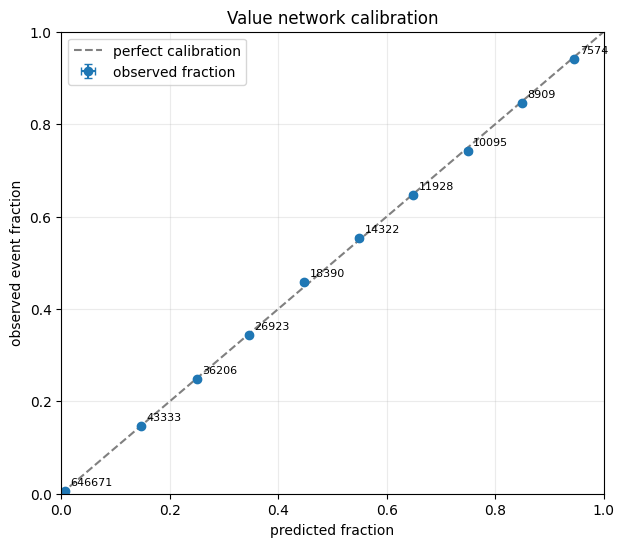

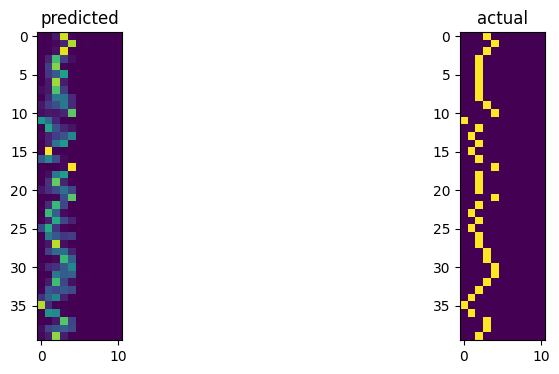

array([<Axes: title={'center': 'predicted'}>,
       <Axes: title={'center': 'actual'}>], dtype=object)

In [12]:
value_predictions = stats.create_prediction_dataframe(
    value_network,
    value_validation_data,
    score_values=np.arange(-5, 6),
)
value_stats = stats.compute_stats(value_predictions, seed=0)
stats.print_stats(value_stats)
stats.plot_calibration(value_stats, title="Value network calibration")
stats.plot_score_heatmaps(
    nn.softmax(value_network.run(value_validation_data.input_features[:, :, None])),
    value_validation_data.answers,
)


expected-score R²: 0.574 ± 0.000
P(actual score): 0.438 ± 0.001
negative log P(actual): 1.036 ± 0.003


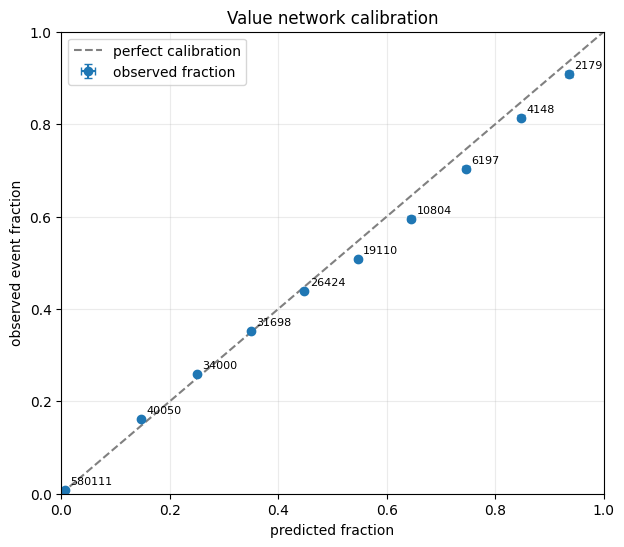

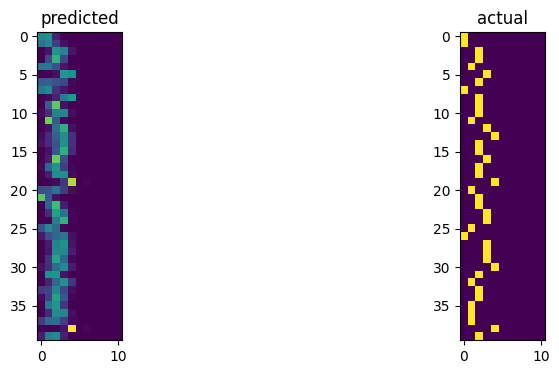

array([<Axes: title={'center': 'predicted'}>,
       <Axes: title={'center': 'actual'}>], dtype=object)

In [33]:
value_predictions = stats.create_prediction_dataframe(
    value_network,
    value_validation_data,
    score_values=np.arange(-5, 6),
)
value_stats = stats.compute_stats(value_predictions, seed=0)
stats.print_stats(value_stats)
stats.plot_calibration(value_stats, title="Value network calibration")
stats.plot_score_heatmaps(
    nn.softmax(value_network.run(value_validation_data.input_features[:, :, None])),
    value_validation_data.answers,
)


expected-score R²: 0.573 ± 0.000
P(actual score): 0.484 ± 0.001
negative log P(actual): 0.975 ± 0.003


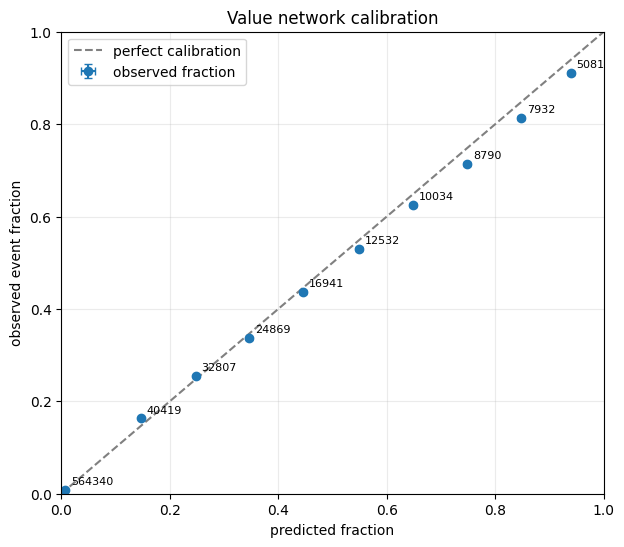

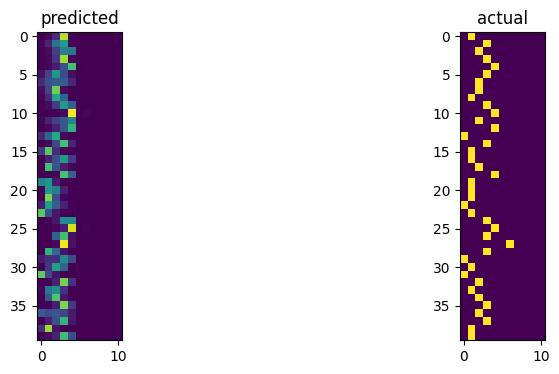

array([<Axes: title={'center': 'predicted'}>,
       <Axes: title={'center': 'actual'}>], dtype=object)

In [15]:
value_predictions = stats.create_prediction_dataframe(
    value_network,
    value_validation_data,
    score_values=np.arange(-5, 6),
)
value_stats = stats.compute_stats(value_predictions, seed=0)
stats.print_stats(value_stats)
stats.plot_calibration(value_stats, title="Value network calibration")
stats.plot_score_heatmaps(
    nn.softmax(value_network.run(value_validation_data.input_features[:, :, None])),
    value_validation_data.answers,
)


## q network (last throw)


In [ ]:
neural_network = curling_nn.QNetwork(seed=0, num_stones=9, hidden_layer_size=20)
loss_function = nn.SoftmaxCrossEntropyLoss()


In [ ]:
generate_new_q_data = True
q_shard_names = None

if generate_new_q_data:
    # TODO: training data should have throws from both teams?
    seed_states = data_generation.random_sheet_states(
        team1=5,
        team2=4,
        num_sims=1000,
    )
    data = data_generation.q_network_training_data(
        sheet_states=seed_states,
        team=1,
        rng=np.random.default_rng(0),
        n_random_throws=1,
        n_per_score=30,
    )
    shard_path = dataset.write_training_data_shard(
        constants.q_network_datasets_dir, data, seed=0
    )
    print(f"wrote shard {shard_path}")

data = dataset.load_training_data_dir(
    constants.q_network_datasets_dir, names=q_shard_names
)
print(f"dataset size: {data.size()}")


In [ ]:
data, validation_data = data.partition(0.2, seed=0)


In [ ]:
losses = []
val_losses = []
num_points_per_batch = 100
num_iters = 30

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )
    val_losses.append(
        neural_network.get_average_loss_batched(
            validation_data.input_features, validation_data.answers, loss_function
        )
    )


In [ ]:
curling_nn.write_q_weights(
    constants.q_network_weights_path,
    neural_network,
    data.normalizer,
)
print(f"wrote weights to {constants.q_network_weights_path}")


In [ ]:
stats.plot_training_losses(losses, val_losses)


In [ ]:
q_predictions = stats.create_prediction_dataframe(
    neural_network,
    validation_data,
    score_values=np.arange(-5, 6),
)
q_stats = stats.compute_stats(q_predictions, seed=0)
stats.print_stats(q_stats)
stats.plot_calibration(q_stats, title="Q network calibration")
stats.plot_score_heatmaps(
    nn.softmax(neural_network.run(validation_data.input_features[:, :, None])),
    validation_data.answers,
)


## eval states


In [2]:

import importlib
import data_generation
importlib.reload(data_generation)



eval_states = data_generation.random_sheet_states(
    team1=5,
    team2=4,
    num_sims=300,
)
num_stones_per_side = 5
team = 1
rng = np.random.default_rng(2026)

import curling_nn
from constants import q_network_weights_path

neural_network, normalizer = curling_nn.load_q_weights(
  q_network_weights_path
)

print(neural_network.num_stones)



9


In [ ]:
grid_search_best_throws = data_generation.best_throws_for_sheets(

    sheet_states = eval_states,

    team = team,

    throw_searcher = bot.ThrowsGridSearcher(10, 10, 4),

    scoring_function=bot.score_throws_by_net_score,

)


In [4]:
neural_net_best_throws = data_generation.best_throws_for_sheets_by_nn(
      sheet_states=eval_states,
      team=team,
      throw_searcher=bot.ThrowsGridSearcher(10, 10, 4),
      neural_network=neural_network,
      normalizer=normalizer,
  )


In [5]:
nn_pred_scorer = data_generation.scoring_function_of_nn(neural_network, normalizer)
get_nn_pred_score_stdev = data_generation.scoring_function_of_nn_score_std(neural_network, normalizer)

grid_search_actual_scores = data_generation.score_throws_by_actual_score(eval_states, grid_search_best_throws)
grid_search_pred_scores = nn_pred_scorer(eval_states, grid_search_best_throws)
grid_search_pred_score_stdevs = get_nn_pred_score_stdev(eval_states, grid_search_best_throws)

nn_best_actual_scores = data_generation.score_throws_by_actual_score(eval_states, neural_net_best_throws)
nn_best_pred_scores = nn_pred_scorer(eval_states, neural_net_best_throws)
nn_best_pred_score_stdevs = get_nn_pred_score_stdev(eval_states, neural_net_best_throws)


Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.


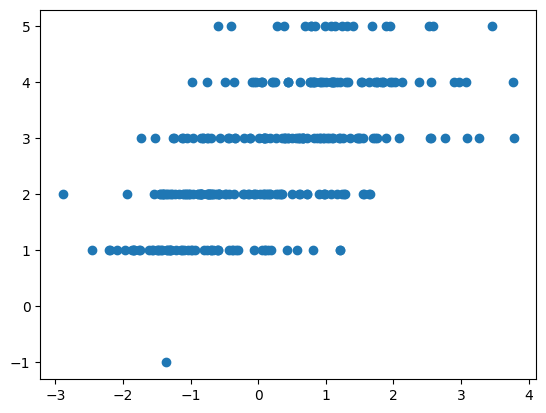

In [6]:
plt.scatter(grid_search_pred_scores, grid_search_actual_scores)


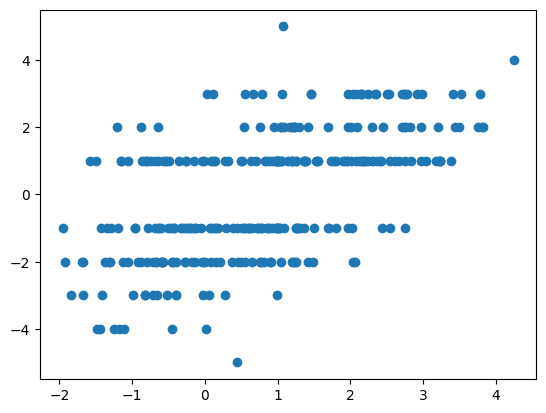

In [7]:
plt.scatter(nn_best_pred_scores, nn_best_actual_scores)


In [10]:
import pandas as pd

score_comparison = pd.DataFrame({
    "state": np.arange(300),
    "grid_search_pred_score": grid_search_pred_scores,
    "grid_search_actual_score": grid_search_actual_scores,
    "grid_search_pred_score_stdev": grid_search_pred_score_stdevs,
    "nn_best_actual_score": nn_best_actual_scores,
    "nn_best_pred_score": nn_best_pred_scores,
    "nn_best_pred_score_stdev": nn_best_pred_score_stdevs
})


In [16]:
(score_comparison["grid_search_actual_score"] - score_comparison["grid_search_pred_score"]).mean()


np.float64(2.4875211347211477)

In [17]:
(score_comparison["nn_best_actual_score"] - score_comparison["nn_best_pred_score"]).mean()


np.float64(-0.7913677465451975)

In [18]:
score_comparison["grid_search_pred_score"].mean()


np.float64(0.1458121986121858)

In [19]:
score_comparison["nn_best_pred_score"].mean()


np.float64(0.7947010798785309)

## Q training notes

20x20
expected score val r^2 0.79ish

30x30
expected_score_val_r2 = 0.8060334892941788, frac max prob = actual 0.834925
extra layer
expected_score_val_r2 = 0.7993249671623189, frac max prob = actual 0.8349
100x100
expected_score_val_r2 = 0.8282151091910064, frac max prob = actual 0.83515
20x20 with new features
expected_score_val_r2 = 0.8044039307457008, frac max prob = actual 0.82885
100x100 with new features
expected_score_val_r2 = 0.8274895115689724, frac max prob = actual 0.835
100x100 with new features and 30 training iters
